In [1]:
## Extract data

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

df = pd.read_csv(r"../../../data/raw/real-estate.csv")
features = ["Prix","Surface","Nb_Pieces"]
X = df[features].copy()
X_scaled = RobustScaler().fit_transform(X) #modif 1 - StandardScanner to RobustScanner
print(df.shape)
df.head()

(50, 5)


,Property_ID,Prix,Surface,Nb_Pieces,Age_Bien
0,P1,1386880,238,1,11
1,P2,804999,282,5,12
2,P3,631593,196,5,12
3,P4,2355723,125,2,28
4,P5,2548988,58,1,14


In [41]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
best_params, search_results, labels = propose_best_dbscan_params(X_pca)
print("--- Meilleurs Paramètres ---")
print(f"Epsilon (eps) : {best_params['eps']}")
print(f"Min Samples   : {best_params['min_samples']}")

display(search_results.head())

--- Meilleurs Paramètres ---
Epsilon (eps) : 0.3
Min Samples   : 6


,eps,min_samples,Nb_clusters,Noise_ratio,Silhouette,Davies_Bouldin,Combined_score
0,0.3,6,4,0.44,0.610468,0.492350,0.519850
1,0.3,5,3,0.30,0.533418,0.570183,0.459909
2,0.4,8,2,0.32,0.534410,0.687328,0.452043
3,0.4,7,2,0.22,0.494205,0.737946,0.424307
4,0.4,5,2,0.18,0.477944,0.757345,0.413077


In [ ]:
## Courbe k-distance

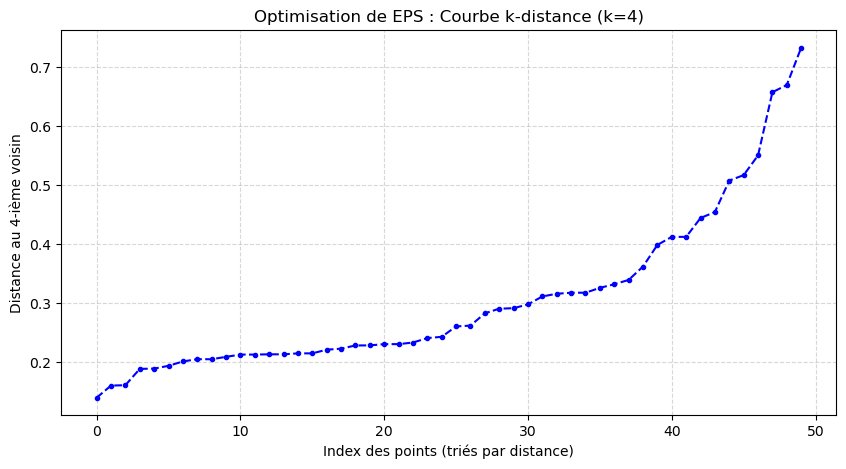

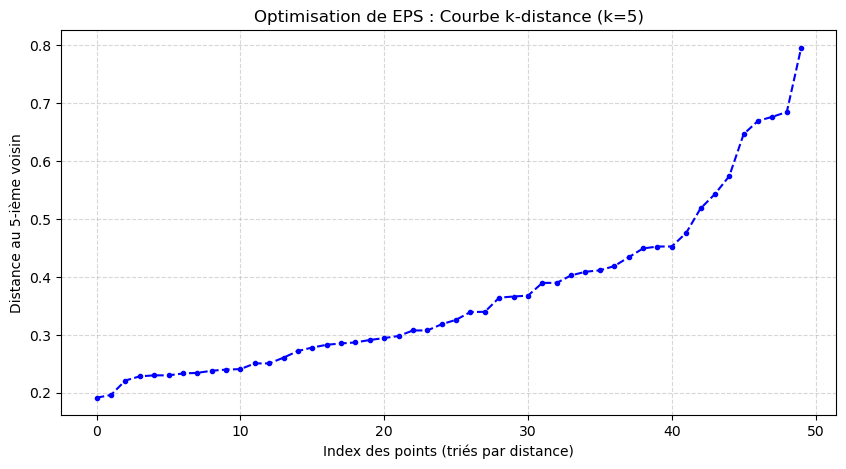

In [42]:
def plot_k_distance_curve(X, k=5):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    
    # kneighbors renvoie (distances, indices). On ne garde que les distances.
    distances, _ = nn.kneighbors(X)
    
    # On prend la distance du k-ième voisin (la dernière colonne)
    kth_distances = np.sort(distances[:, -1])
    
    # Visualisation
    plt.figure(figsize=(10, 5))
    plt.plot(kth_distances, marker='.', linestyle='--', color='b')
    plt.title(f"Optimisation de EPS : Courbe k-distance (k={k})")
    plt.xlabel("Index des points (triés par distance)")
    plt.ylabel(f"Distance au {k}-ième voisin")
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    # Ajout d'une ligne horizontale indicative si tu as une idée du coude
    # plt.axhline(y=1.2, color='r', linestyle='-') 
    
    plt.show()
    
    # On retourne les distances pour pouvoir les analyser hors graphique
    return kth_distances## Recherche automatique des paramètres

# Utilisation sur tes données normalisées et réduites par PCA
k_opti = 4 
distances_triees = plot_k_distance_curve(X_pca, k=k_opti)

_ = plot_k_distance_curve(X_pca, k=5)

In [ ]:
## Recherche automatique des paramètres

In [43]:
def propose_best_dbscan_params(X, eps_values=None, min_samples_values=None):
    if eps_values is None:
        eps_values = np.round(np.arange(0.30, 1.81, 0.10), 2)
    if min_samples_values is None:
        min_samples_values = range(3, 9)

    rows = []
    best_score = -np.inf
    best_params = None
    best_labels = None

    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=float(eps), min_samples=int(min_samples))
            labels = model.fit_predict(X)

            unique_labels = set(labels)
            n_clusters = len(unique_labels - {-1}) if -1 in unique_labels else len(unique_labels)
            noise_ratio = np.mean(np.array(labels) == -1)

            if n_clusters < 2:
                continue

            mask = np.array(labels) != -1
            filtered_X = X[mask]
            filtered_labels = np.array(labels)[mask]

            if len(set(filtered_labels)) < 2 or len(filtered_X) <= len(set(filtered_labels)):
                continue

            sil = silhouette_score(filtered_X, filtered_labels)
            db = davies_bouldin_score(filtered_X, filtered_labels)
            combined_score = sil - 0.15 * noise_ratio - 0.05 * db

            rows.append({
                "eps": eps,
                "min_samples": min_samples,
                "Nb_clusters": n_clusters,
                "Noise_ratio": noise_ratio,
                "Silhouette": sil,
                "Davies_Bouldin": db,
                "Combined_score": combined_score
            })

            if combined_score > best_score:
                best_score = combined_score
                best_params = {"eps": eps, "min_samples": min_samples}
                best_labels = labels

    results = pd.DataFrame(rows).sort_values("Combined_score", ascending=False).reset_index(drop=True)
    return best_params, results, best_labels

best_params, search_results, labels = propose_best_dbscan_params(X_pca)
print("Paramètres proposés :", best_params)
display(search_results.head(10))

Paramètres proposés : {'eps': np.float64(0.3), 'min_samples': 6}


,eps,min_samples,Nb_clusters,Noise_ratio,Silhouette,Davies_Bouldin,Combined_score
0,0.3,6,4,0.44,0.610468,0.492350,0.519850
1,0.3,5,3,0.30,0.533418,0.570183,0.459909
2,0.4,8,2,0.32,0.534410,0.687328,0.452043
3,0.4,7,2,0.22,0.494205,0.737946,0.424307
4,0.4,5,2,0.18,0.477944,0.757345,0.413077
5,0.4,6,2,0.18,0.477944,0.757345,0.413077
6,0.5,8,2,0.16,0.467824,0.793081,0.404170
7,0.3,4,4,0.16,0.457193,0.662449,0.400071
8,0.3,3,3,0.14,0.415389,0.731322,0.357823
9,0.4,4,2,0.10,0.160687,0.829289,0.104223


In [44]:
## Evaluation et visualisation

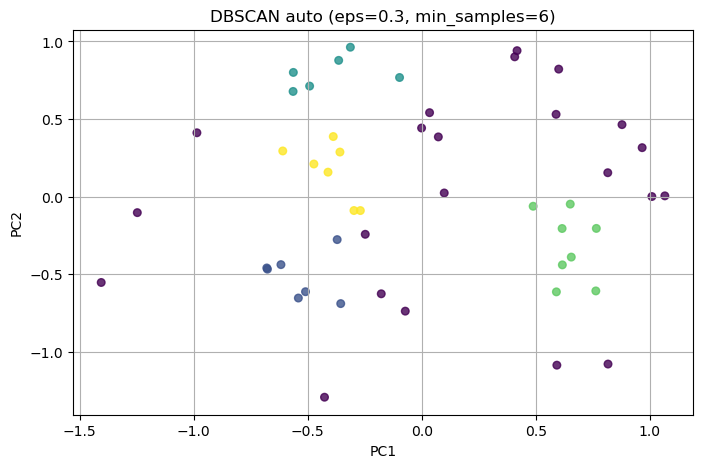

Silhouette : 0.3422
Davies-Bouldin : 1.1141
Taux de bruit : 0.44


,Property_ID,Prix,Surface,Nb_Pieces,Age_Bien,Cluster_DBSCAN
0,P1,1386880,238,1,11,3
1,P2,804999,282,5,12,-1
2,P3,631593,196,5,12,-1
3,P4,2355723,125,2,28,-1
4,P5,2548988,58,1,14,-1


In [45]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=30, alpha=0.8)
plt.title(f"DBSCAN auto (eps={best_params['eps']}, min_samples={best_params['min_samples']})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

mask = np.array(labels) != -1
sil = silhouette_score(X_scaled[mask], np.array(labels)[mask])
dbi = davies_bouldin_score(X_scaled[mask], np.array(labels)[mask])
noise_ratio = np.mean(np.array(labels) == -1)

print("Silhouette :", round(sil, 4))
print("Davies-Bouldin :", round(dbi, 4))
print("Taux de bruit :", round(noise_ratio, 4))

df_result = df.copy()
df_result["Cluster_DBSCAN"] = labels
df_result.head()